In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
RAW_DATA_DIR = "../data/raw"


books = pd.read_csv(f"{RAW_DATA_DIR}/Books.csv", low_memory=False)
ratings = pd.read_csv(f"{RAW_DATA_DIR}/Ratings.csv", low_memory=False)
users = pd.read_csv(f"{RAW_DATA_DIR}/Users.csv", low_memory=False)

In [17]:
books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [18]:
ratings

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [19]:
users

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN
...,...,...,...
278853,278854,"portland, oregon, usa",NaN
278854,278855,"tacoma, washington, united kingdom",50.0
278855,278856,"brampton, ontario, canada",NaN
278856,278857,"knoxville, tennessee, usa",NaN


In [20]:
# Check for null values in each DataFrame
for name, df in [("Books", books), ("Ratings", ratings), ("Users", users)]:
    print(f"\n{name}:")
    null_counts = df.isnull().sum()
    for column, count in null_counts.items():
        if count > 0:
            print(f"\033[91m {column:<25}: {count} null values\033[0m")
        else:
            print(f" {column:<25}: No null values")


Books:
 ISBN                     : No null values
 Book-Title               : No null values
 Book-Author              : 2 null values
 Year-Of-Publication      : No null values
 Publisher                : 2 null values
 Image-URL-S              : No null values
 Image-URL-M              : No null values
 Image-URL-L              : 3 null values

Ratings:
 User-ID                  : No null values
 ISBN                     : No null values
 Book-Rating              : No null values

Users:
 User-ID                  : No null values
 Location                 : No null values
 Age                      : 110762 null values


In [21]:
# Check for duplicate entries in each DataFrame
for name, df in [("Books", books), ("Ratings", ratings), ("Users", users)]:
    print(f"\n{name}:")
    duplicate_count = df.duplicated().sum()
    if duplicate_count == 0:
        print(" No duplicate entries found.")
    else:
        print(f" {duplicate_count:,} duplicate entries found.")


Books:
 No duplicate entries found.

Ratings:
 No duplicate entries found.

Users:
 No duplicate entries found.


In [22]:
# Check rating distribution
rating_counts = ratings["Book-Rating"].value_counts().sort_index()
for rating, count in rating_counts.items():
    print(f" {rating}: {count:,} ratings ({count / len(ratings) * 100:.1f}%)")

 0: 716,109 ratings (62.3%)
 1: 1,770 ratings (0.2%)
 2: 2,759 ratings (0.2%)
 3: 5,996 ratings (0.5%)
 4: 8,904 ratings (0.8%)
 5: 50,974 ratings (4.4%)
 6: 36,924 ratings (3.2%)
 7: 76,457 ratings (6.6%)
 8: 103,736 ratings (9.0%)
 9: 67,541 ratings (5.9%)
 10: 78,610 ratings (6.8%)


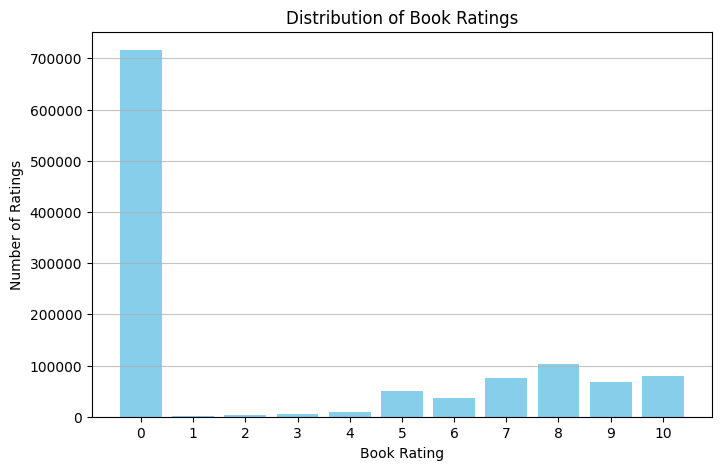

In [23]:
# Plot rating distribution
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color="skyblue")
plt.xlabel("Book Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Book Ratings")
plt.xticks(rating_counts.index)
plt.grid(axis="y", alpha=0.75)
plt.show()

In [24]:
# Check how many unque users and books are in the ratings dataset
unique_users = ratings["User-ID"].nunique()
unique_books = ratings["ISBN"].nunique()
print(f"Unique users in ratings: {unique_users:,}")
print(f"Unique books in ratings: {unique_books:,}")
print(f"Non-unique users: {len(ratings) - unique_users:,}")
print(f"Non-unique books: {len(ratings) - unique_books:,}")

Unique users in ratings: 105,283
Unique books in ratings: 340,556
Non-unique users: 1,044,497
Non-unique books: 809,224


In [25]:
# Check how many books have few ratings (0, 1, 2) 
book_rating_counts = ratings["ISBN"].value_counts()
books_with_no_ratings = book_rating_counts[book_rating_counts == 0].count()
books_with_one_rating = book_rating_counts[book_rating_counts == 1].count()
books_with_two_ratings = book_rating_counts[book_rating_counts == 2].count()
print(f"Books with no ratings: {books_with_no_ratings:,} ({books_with_no_ratings / unique_books * 100:.1f}%)")
print(f"Books with one rating: {books_with_one_rating:,} ({books_with_one_rating / unique_books * 100:.1f}%)")
print(f"Books with two ratings: {books_with_two_ratings:,} ({books_with_two_ratings / unique_books * 100:.1f}%)")
print(f"Books with 0-2 ratings: {books_with_no_ratings + books_with_one_rating + books_with_two_ratings:,} ({(books_with_no_ratings + books_with_one_rating + books_with_two_ratings) / unique_books * 100:.1f}%)")

# Check how many users have only rated one book
user_rating_counts = ratings["User-ID"].value_counts()
users_with_one_rating = user_rating_counts[user_rating_counts == 1].count()
print(f"Users with only one rating: {users_with_one_rating:,} ({users_with_one_rating / unique_users * 100:.1f}%)")

Books with no ratings: 0 (0.0%)
Books with one rating: 197,045 (57.9%)
Books with two ratings: 59,664 (17.5%)
Books with 0-2 ratings: 256,709 (75.4%)
Users with only one rating: 59,166 (56.2%)


In [26]:
# Sort books by rating count and show top 10 (excluding those with zero ratings)
top_books = book_rating_counts.sort_values(ascending=False).head(10)
print("\nTop 10 most rated books:")

for isbn, count in top_books.items():
    matching = books[books["ISBN"] == isbn]["Book-Title"]
    if not matching.empty:
        book_title = matching.iloc[0]
        print(f" {book_title} (ISBN: {isbn}): {count:,} ratings")
    else:
        print(f" [UNKNOWN TITLE] (ISBN: {isbn}): {count:,} ratings")

# Show bottom 10 least rated books (excluding those with zero ratings)
bottom_books = book_rating_counts.sort_values(ascending=True).head(10)
print("\nBottom 10 least rated books:")
for isbn, count in bottom_books.items():
    matching = books[books["ISBN"] == isbn]["Book-Title"]
    if not matching.empty:
        book_title = matching.iloc[0]
        print(f" {book_title} (ISBN: {isbn}): {count:,} ratings")
    else:
        print(f" [UNKNOWN TITLE] (ISBN: {isbn}): {count:,} ratings")


Top 10 most rated books:
 Wild Animus (ISBN: 0971880107): 2,502 ratings
 The Lovely Bones: A Novel (ISBN: 0316666343): 1,295 ratings
 The Da Vinci Code (ISBN: 0385504209): 883 ratings


 Divine Secrets of the Ya-Ya Sisterhood: A Novel (ISBN: 0060928336): 732 ratings
 The Red Tent (Bestselling Backlist) (ISBN: 0312195516): 723 ratings
 A Painted House (ISBN: 044023722X): 647 ratings
 [UNKNOWN TITLE] (ISBN: 0679781587): 639 ratings
 The Secret Life of Bees (ISBN: 0142001740): 615 ratings
 Snow Falling on Cedars (ISBN: 067976402X): 614 ratings
 Angels &amp; Demons (ISBN: 0671027360): 586 ratings

Bottom 10 least rated books:
 The Men We Became : My Friendship with John F. Kennedy, Jr. (ISBN: 0312324766): 1 ratings
 Bellefleur (ISBN: 0452267943): 1 ratings
 A MARRIAGE MADE AT WOODSTOCK (ISBN: 0671516949): 1 ratings
 The WEIGHT OF WINTER (ISBN: 067179387X): 1 ratings
 VERA (ISBN: 0671883917): 1 ratings
 The Glory Cloak : A Novel of Louisa May Alcott and Clara Barton (ISBN: 0743257502): 1 ratings
 A Guided Tour of Rene Descartes' Meditations on First Philosophy with Complete Translations of the Meditations by Ronald Rubin (ISBN: 0767409752): 1 ratings
 If It's Not Close, Th

In [27]:
# Books by average rating (only include books with at least 10 ratings)
book_avg_ratings = ratings.groupby("ISBN")["Book-Rating"].mean()
book_rating_counts = ratings["ISBN"].value_counts()
books_with_10_or_more_ratings = book_rating_counts[book_rating_counts >= 10].index
avg_ratings_for_popular_books = book_avg_ratings[books_with_10_or_more_ratings].sort_values(ascending=False)
print("\nTop 10 highest rated books (with at least 10 ratings):")
for isbn, avg_rating in avg_ratings_for_popular_books.head(10).items():
    matching = books[books["ISBN"] == isbn]["Book-Title"]
    if not matching.empty:
        book_title = matching.iloc[0]
        print(f" {book_title} (ISBN: {isbn}): Average Rating {avg_rating:.2f}")
    else:
        print(f" [UNKNOWN TITLE] (ISBN: {isbn}): Average Rating {avg_rating:.2f}")


Top 10 highest rated books (with at least 10 ratings):
 The Blue Day Book: A Lesson in Cheering Yourself Up (ISBN: 0091842050): Average Rating 9.18
 Love You Forever (ISBN: 0920668364): Average Rating 8.50
 The Baby Book: Everything You Need to Know About Your Baby from Birth to Age Two (ISBN: 0316779059): Average Rating 8.46
 The Outlandish Companion (ISBN: 0385324138): Average Rating 8.30
 The Lorax (ISBN: 0394823370): Average Rating 8.17
 The Princess Bride: S. Morgenstern's Classic Tale of True Love and High Adventure (The 'Good Parts' Version) (ISBN: 034543014X): Average Rating 8.10
 Die unendliche Geschichte: Von A bis Z (ISBN: 3522128001): Average Rating 8.07
 Marching Through Culpeper : A Novel of Culpeper, Virginia, Crossroads of the Civil War (ISBN: 0615116426): Average Rating 8.07
 [UNKNOWN TITLE] (ISBN: 0006513220): Average Rating 8.00
 The Sneetches and Other Stories (ISBN: 0394800893): Average Rating 8.00


In [28]:
# How many books survive data cleaning
# Exclude ratings = 0, remove duplicate user-ISBN pairs
ratings_clean = ratings[ratings["Book-Rating"] > 0]
ratings_clean = ratings_clean.drop_duplicates(["User-ID", "ISBN"])

# Exclude books with less than 3 ratings
book_counts = ratings_clean["ISBN"].value_counts()
popular_isbns = book_counts[book_counts >= 3].index

# Exclude missing titles/authors and duplicate ISBN entries
books_clean = books.dropna(subset=["Book-Title", "Book-Author"])
books_clean = books_clean.drop_duplicates("ISBN")

# Calculate how many books survive cleaning
books_final = books_clean[books_clean["ISBN"].isin(popular_isbns)]

total_raw      = books["ISBN"].nunique()
total_popular  = len(popular_isbns)
total_survived = len(books_final)
orphans        = total_popular - total_survived

print(f"Total Unique ISBNs (Raw)          : {total_raw:,}")
print(f"Books with >= 3 explicit ratings  : {total_popular:,}")
print(f"ISBNs in ratings but not in books : {orphans:,}")
print(f"Books that survive cleaning       : {total_survived:,}")

Total Unique ISBNs (Raw)          : 271,360
Books with >= 3 explicit ratings  : 30,091
ISBNs in ratings but not in books : 2,287
Books that survive cleaning       : 27,804
